# Benchmarking the Tuna devices performance using common measurement routines

**Author:** Marios Samiotis (m.samiotis@tudelft.nl)

**Date:** April 29, 2026

**Last updated:** April 29, 2026

# 1. Introduction

In this notebook we will use some of the most common benchmark measurement routines to assess the performance of any of the Tuna superconducting quantum backends which exist at the [Quantum Inspire 2.0](https://www.quantum-inspire.com/) cloud services.

Prior to using this notebook, for optimal performance, make sure that you are running it within a customized Python 3.12 environment which includes the packages "quantuminspire" and "qiskit-quantuminspire".

For details on how to create such a Python environment, follow the installation instructions in the [README file](https://github.com/DiCarloLab-Delft/QuantumInspireUtilities/blob/main/README.md).

Useful links:
1. [Tuna Backends Operational Specifics](https://www.quantum-inspire.com/kbase/tuna-operational-specifics/)
2. [Backend Performance Dashboards](https://monitoring.qutech.support/public-dashboards/c494a21fb6b7405f850ab8f340f798ef?orgId=1&refresh=10s) [live updates]
3. [Join our Slack community!](https://join.slack.com/t/qisuperconducting/shared_invite/zt-35o7zitdh-_9QPmB53hhLy12Eat5gwWA)

First, we run the following cell in order to login to the Quantum Inspire platform. You need an account in order to login to the platform.

Please click on "Confirm" in the pop-up browser window to login.

In [ ]:
! qi login "https://api.quantum-inspire.com"

Run the following cell for all necessary library imports,

In [1]:
import numpy as np
from qiskit_quantuminspire.qi_provider import QIProvider
from qi_utilities.device_simulation.simulators import NoisySimulator # use the simulator in case all backends are unavailable!
from qi_utilities.measurements.device_control import DeviceControl

# 2. Connecting to the backend

We first connect to the Quantum Inspire provider, by running the following cell,

In [ ]:
provider = QIProvider()

The following command prints the full list of all available backends of the platform,

In [ ]:
provider.backends()

We now connect to a Tuna backend by running the following cell,

In [ ]:
backend_name = "Tuna-9"
backend = provider.get_backend(name=backend_name)

In [2]:
backend = NoisySimulator("Starmon-7")

By running the cell below, the connectivity of the processor is shown (otherwise known as "coupling map"),

In [ ]:
backend.coupling_map.draw()

Any single- or multi-qubit gates that may be applied on the qubits of the Tuna backends are referred to as "instructions". The full list of allowed instructions of the Tuna backend is shown by running the following cell,

In [ ]:
backend.instructions

When executing a quantum algorithm on any backend, one needs to choose the number of measurement shots to be performed for the given quantum circuit. The maximum number of allowed shots on the Tuna backend can be obtained by running the command

In [ ]:
backend.max_shots

# DeviceControl class

In [3]:
device = DeviceControl(backend)

In [ ]:
device.measure_rabi(qubit_list=[0],
                    rotation_angles = np.linspace(0, 2*np.pi, num=29))

In [ ]:
device.measure_T1(qubit_list=[1, 5],
                  measurement_times=np.linspace(0, 30e-6, num=7))

In [ ]:
device.measure_T2_ramsey(qubit_list=[0, 5],
                         measurement_times=np.linspace(0, 15e-6, num=61))

In [ ]:
device.measure_T2_echo(qubit_list=[0, 5],
                       measurement_times=np.linspace(0, 15e-6, num=61))

In [ ]:
device.measure_allxy(qubit_list=[1, 5])

In [4]:
from qi_utilities.measurements.base_classes import BaseMeasurement
from qi_utilities.utility_functions.circuit_modifiers import apply_rotations_from_list
from qiskit import QuantumCircuit

class BellStateMeasurement(BaseMeasurement):

    def __init__(self,
                 backend,
                 qubit_pairs: list[list[int]],
                 bell_state: str,
                 num_shots: int,
                 directory: str = None):
        
        self.tomography_bases = [
                    'XX', 'YX', 'ZX', 'XY', 'YY',
                    'ZY', 'XZ', 'YZ', 'ZZ'
                ]
        self.single_qubit_terms = ['IX', 'IY', 'IZ', 'XI', 'YI', 'ZI']
        
        qc = self._quantum_circuit(backend,
                                   qubit_pairs,
                                   bell_state)

        qubit_list = []
        for qubit_pair in qubit_pairs:
            for qubit_idx in qubit_pair:
                if qubit_idx in qubit_list:
                    raise ValueError("A single qubit cannot be used in multiple pairs at the same time!")
                else:
                    qubit_list.append(qubit_idx)
        super().__init__(backend=backend,
                         qubit_list=qubit_list,
                         qc=qc,
                         num_shots=num_shots,
                         n_qubit_routine=2,
                         qubit_groups = qubit_pairs,
                         directory=directory)


    def _quantum_circuit(self,
                         backend,
                         qubit_pairs: list[list[int]],
                         bell_state: str):

        def create_bell_states(qc: QuantumCircuit,
                               qubit_pairs: list[list[int]],
                               bell_state: str):
            
            bell_state_rotations = {
                "phi_plus": [0.0, 0.0],
                "phi_minus": [np.pi, 0.0],
                "psi_plus": [0.0, np.pi],
                "psi_minus": [np.pi, np.pi]
            }

            for qubit_pair in qubit_pairs:
                for qubit_idx in qubit_pair:        
                    qc.reset(qubit_idx)
            for qubit_pair in qubit_pairs:
                qc.rx(bell_state_rotations[bell_state][0], qubit_pair[0])
                qc.rx(bell_state_rotations[bell_state][1], qubit_pair[1])
            qc.barrier()
            for qubit_pair in qubit_pairs:
                qc.h(qubit_pair[0])
                qc.cx(qubit_pair[0], qubit_pair[1])
            qc.barrier()

            return qc
        
        qc = QuantumCircuit(backend.num_qubits,
                            2*len(qubit_pairs)*len(self.tomography_bases),
                            name=f'Bell_State_Tomography')
        
        bit_idx = 0
        for tomography_basis in self.tomography_bases:

            qc = create_bell_states(qc,
                                    qubit_pairs,
                                    bell_state)
            for qubit_pair in qubit_pairs:
        
                apply_rotations_from_list(qc,
                                        tomography_basis,
                                        qubit_pair,
                                        np.arange(bit_idx, bit_idx+len(tomography_basis)))
                bit_idx += 2
            qc.barrier()
        return qc

In [5]:
meas_bell_state = BellStateMeasurement(backend,
                                       qubit_pairs = [[0, 2],
                                                      [1, 3]],
                                       bell_state = "phi_plus",
                                       num_shots = 2**12)

probs = meas_bell_state.ro_corrected_probs_per_n_qubits

In [7]:
from qi_utilities.utility_functions.raw_data_processing import translate_to_Z_basis, observable_expectation_values_Z_basis
import matplotlib.pyplot as plt

tomography_bases = [
            'XX', 'YX', 'ZX', 'XY', 'YY',
            'ZY', 'XZ', 'YZ', 'ZZ'
        ]
single_qubit_terms = ['IX', 'IY', 'IZ', 'XI', 'YI', 'ZI']

In [6]:
import numpy as np
from qiskit.quantum_info import Pauli, Operator

def create_density_state(tomography_dict):

    density_matrix = np.zeros((4, 4), dtype=complex)
    for label, value in tomography_dict.items():
        pauli_op = Operator(Pauli(label)).data
        density_matrix += (1/4) * value * pauli_op

    return density_matrix

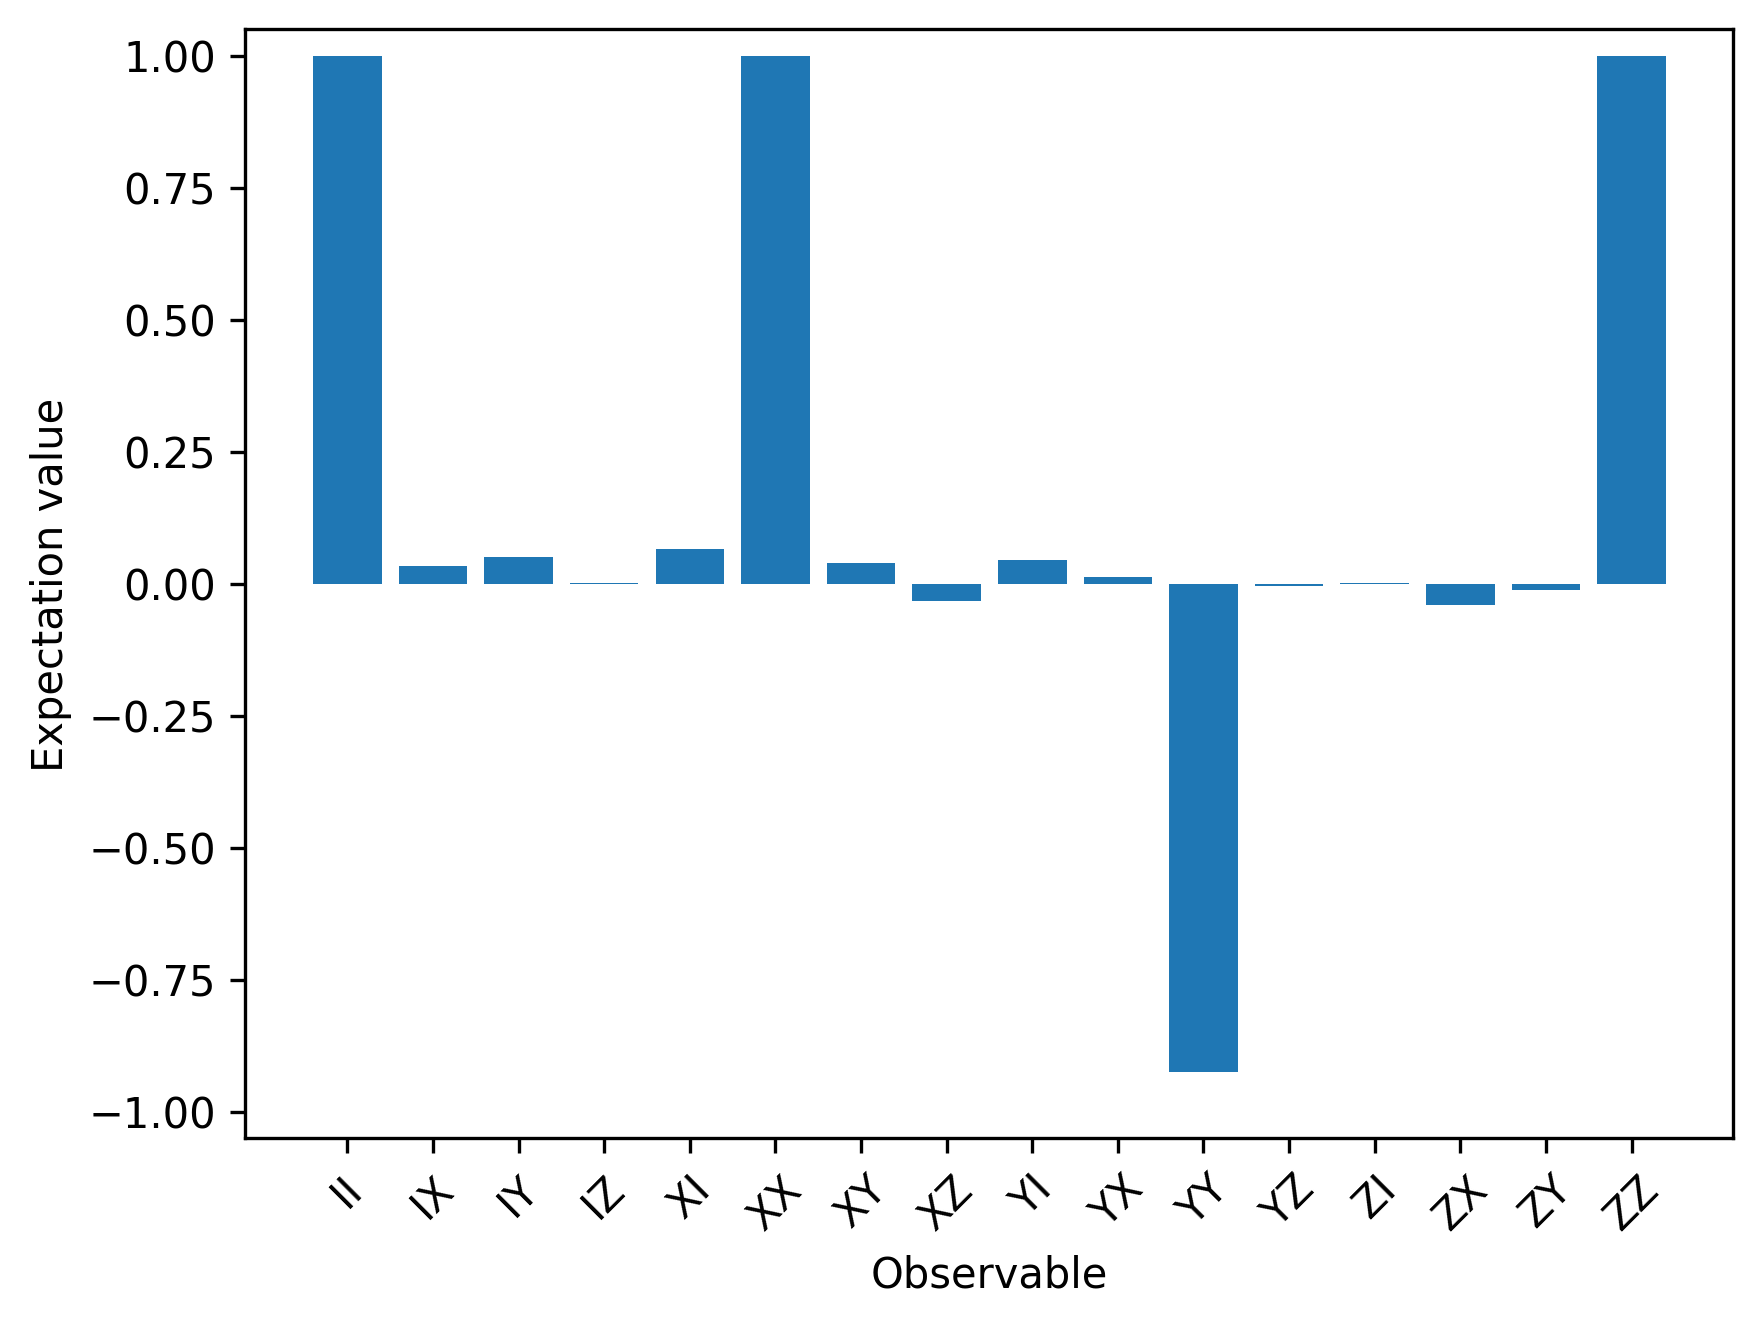

In [ ]:
tomography_dict = {'II': np.float64(1.0)}
for pauli_term_idx in range(len(tomography_bases)):
    pauli_term = tomography_bases[pauli_term_idx]
    pauli_term_in_Z = translate_to_Z_basis(pauli_term)
    tomography_dict[pauli_term] = observable_expectation_values_Z_basis([probs[0][pauli_term_idx]],
                                                             pauli_term_in_Z)[0]
    
for sq_pauli_term_idx in range(len(single_qubit_terms)):
    sq_pauli_term = single_qubit_terms[sq_pauli_term_idx]
    sq_pauli_term_stripped = sq_pauli_term.replace("I", "")
    sq_pauli_term_idx = sq_pauli_term.index(sq_pauli_term_stripped)
    for pauli_term_idx in range(len(tomography_bases)):
        pauli_term = tomography_bases[pauli_term_idx]
        if sq_pauli_term_stripped == pauli_term[sq_pauli_term_idx]:
            sq_pauli_term_in_Z = translate_to_Z_basis(sq_pauli_term)
            tomography_dict[sq_pauli_term] = observable_expectation_values_Z_basis([probs[0][pauli_term_idx]],
                                                                                      sq_pauli_term_in_Z)[0]
            
pauli_labels = []
for i_idx in ['I', 'X', 'Y', 'Z']:
    for j_idx in ['I', 'X', 'Y', 'Z']:
        pauli_labels.append(i_idx+j_idx)
tomography_dict = {pauli_term: tomography_dict[pauli_term] for pauli_term in pauli_labels}
tomography_values = [tomography_dict[pauli_term] for pauli_term in tomography_dict.keys()]

fig, ax = plt.subplots(dpi=300)
ax.bar(range(len(tomography_values)), tomography_values)

ax.set_xticks(range(len(tomography_values)), pauli_labels, rotation=45)
ax.set_xlabel("Observable")
ax.set_ylabel("Expectation value")
ax.set_ylim(-1.05, 1.05)

plt.show()

In [9]:
density_matrix = create_density_state(tomography_dict)

In [10]:
density_matrix_real = np.real(density_matrix)
density_matrix_imag = np.imag(density_matrix)

In [11]:
density_matrix_real

array([[ 0.50054714, -0.00133649,  0.00855719,  0.48102655],
       [-0.00133649,  0.        ,  0.01897345,  0.02469233],
       [ 0.00855719,  0.01897345,  0.        ,  0.01862623],
       [ 0.48102655,  0.02469233,  0.01862623,  0.49945286]])

In [12]:
density_matrix_imag

array([[ 0.        , -0.00947117, -0.01054774, -0.01281535],
       [ 0.00947117,  0.        ,  0.00665977, -0.01226559],
       [ 0.01054774, -0.00665977,  0.        , -0.01581648],
       [ 0.01281535,  0.01226559,  0.01581648,  0.        ]])